In [1]:
!pip install -qq ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 26.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 2

In [2]:
yaml_content = """
train: /kaggle/input/dataset300/train/images
val: /kaggle/input/dataset300/valid/images
test: /kaggle/input/dataset300/test

nc: 4
names: ['ball', 'goalkeeper', 'player', 'referee']
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content)

In [3]:
import os

train_dir = '/kaggle/input/dataset300/train/images'
val_dir = '/kaggle/input/dataset300/valid/images'
test_dir = '/kaggle/input/dataset300/test/images'

# Hitung file dengan ekstensi gambar
train_images_count = len([f for f in os.listdir(train_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
validation_images_count = len([f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_images_count = len([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print("Train set images count:", train_images_count)
print("Validation set images count:", validation_images_count)
print("Test set images count:", test_images_count)

Train set images count: 298
Validation set images count: 49
Test set images count: 25


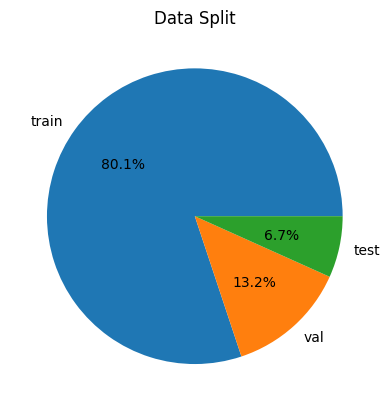

In [4]:
import matplotlib.pyplot as plt
import numpy as np
data = np.array([train_images_count, validation_images_count,
test_images_count])
plt.pie(data,
 labels=['train', 'val', 'test'],
 autopct='%1.1f%%')
plt.title('Data Split')
plt.show();

In [5]:
import yaml

# Buka file data.yaml
with open('/kaggle/working/data.yaml') as f:
    data = yaml.safe_load(f)
    labels = data['names']

# Cetak daftar label
print("Labels are:")
for i, label in enumerate(labels):
    print(f"{i} - {label}")

Labels are:
0 - ball
1 - goalkeeper
2 - player
3 - referee


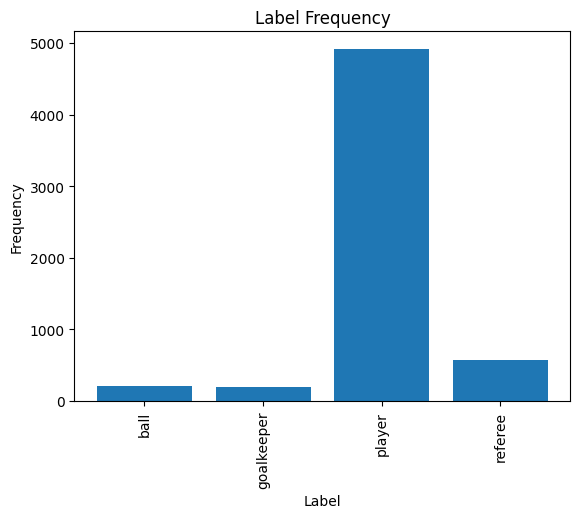

In [7]:
plt.bar(labels, label_freq)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.title("Label Frequency")
plt.show()

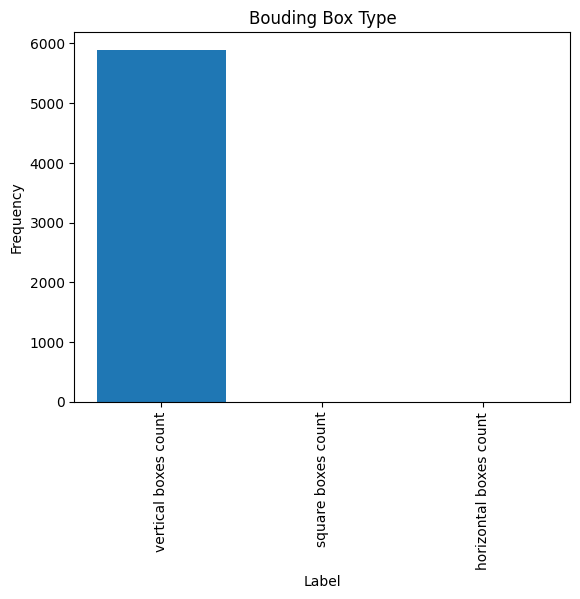

In [8]:
vertical_boxes_count = np.sum([ratio < 0.9 for ratio in aspect_ratios])
square_boxes_count = np.sum([ratio > 0.9 and ratio < 1.1 for ratio in aspect_ratios])
horizontal_boxes_count = np.sum([ratio > 1.1 for ratio in aspect_ratios])

plt.bar(['vertical boxes count', 'square boxes count', 'horizontal boxes count'],
        [vertical_boxes_count, square_boxes_count, horizontal_boxes_count])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.title("Bouding Box Type")
plt.show()

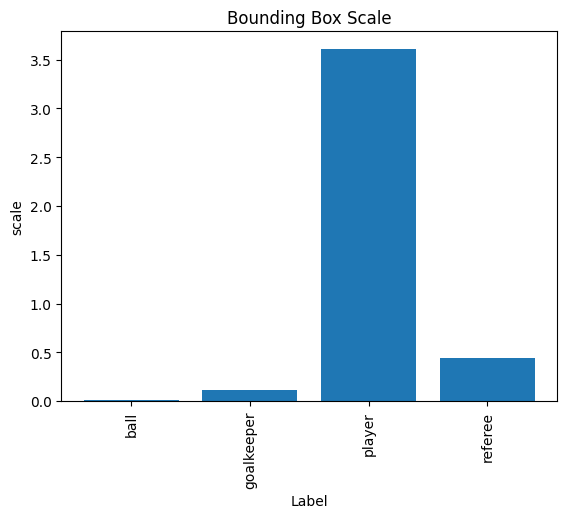

In [9]:
plt.bar(labels, label_scale)
plt.xlabel('Label')
plt.ylabel('scale')
plt.xticks(rotation=90)
plt.title("Bounding Box Scale")
plt.show()

In [12]:
from ultralytics import YOLO

# Load model YOLOv8
model = YOLO('yolov8l.pt')

model.train(
    data='/kaggle/working/data.yaml', 
    
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10, 
    
    optimizer='SGD',  
    lr0=0.01,
    warmup_epochs=3,
    close_mosaic=10,  
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    workers=2,
    
    project='runs/yolo-training', 
    name='deteksipemain',  
    device=0,
    verbose=False
)

Ultralytics 8.4.95 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deteksipemain-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_ma

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         49       1174      0.914      0.803      0.849       0.54
Speed: 0.3ms preprocess, 20.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/runs/yolo-training/deteksipemain-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b0dc006dcd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [13]:
import cv2
from ultralytics import YOLO
model = YOLO('/kaggle/input/deteksi_pemain/pytorch/default/1/best (1).pt')
orig_img = cv2.imread("/kaggle/input/datacobabaru/mbappe 1.png")
result = model(orig_img)[0]


0: 320x640 1 ball, 21 players, 51.2ms
Speed: 2.3ms preprocess, 51.2ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)


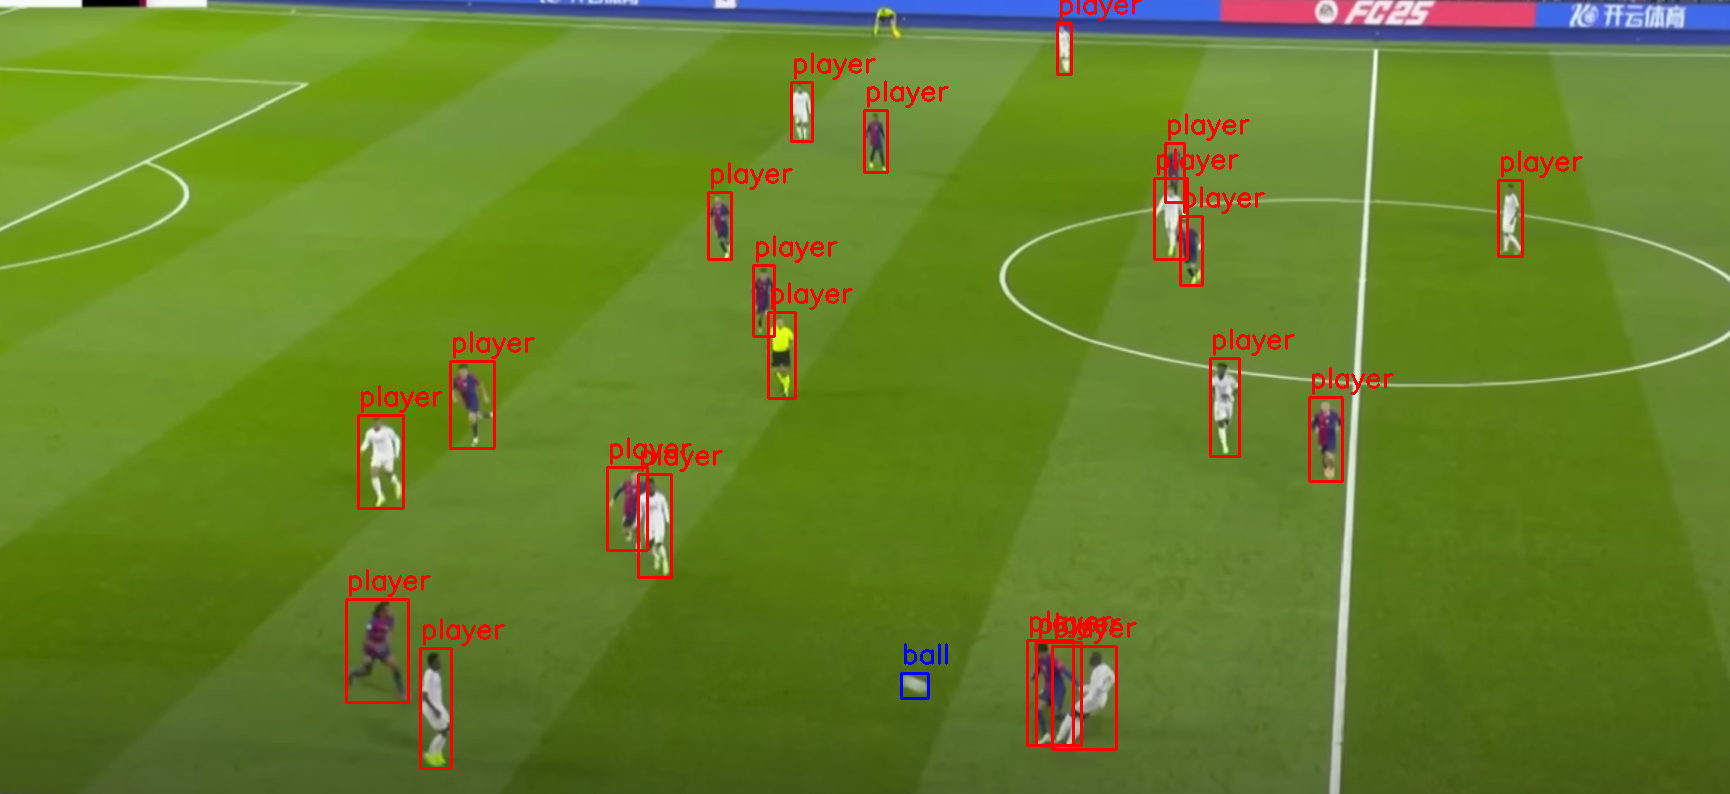

In [14]:
import cv2
from google.colab.patches import cv2_imshow

img = result.orig_img.copy()
box_colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

for box in result.boxes:
    label = int(box.cls.cpu().numpy()[0])  # Memindahkan tensor ke CPU
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())  # Memindahkan tensor ke CPU

    # Gambar bounding box dan label
    cv2.rectangle(img, (x1, y1), (x2, y2), box_colors[int(label)], 2)
    cv2.putText(img, labels[label], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, box_colors[int(label)], 2)

cv2_imshow(img)

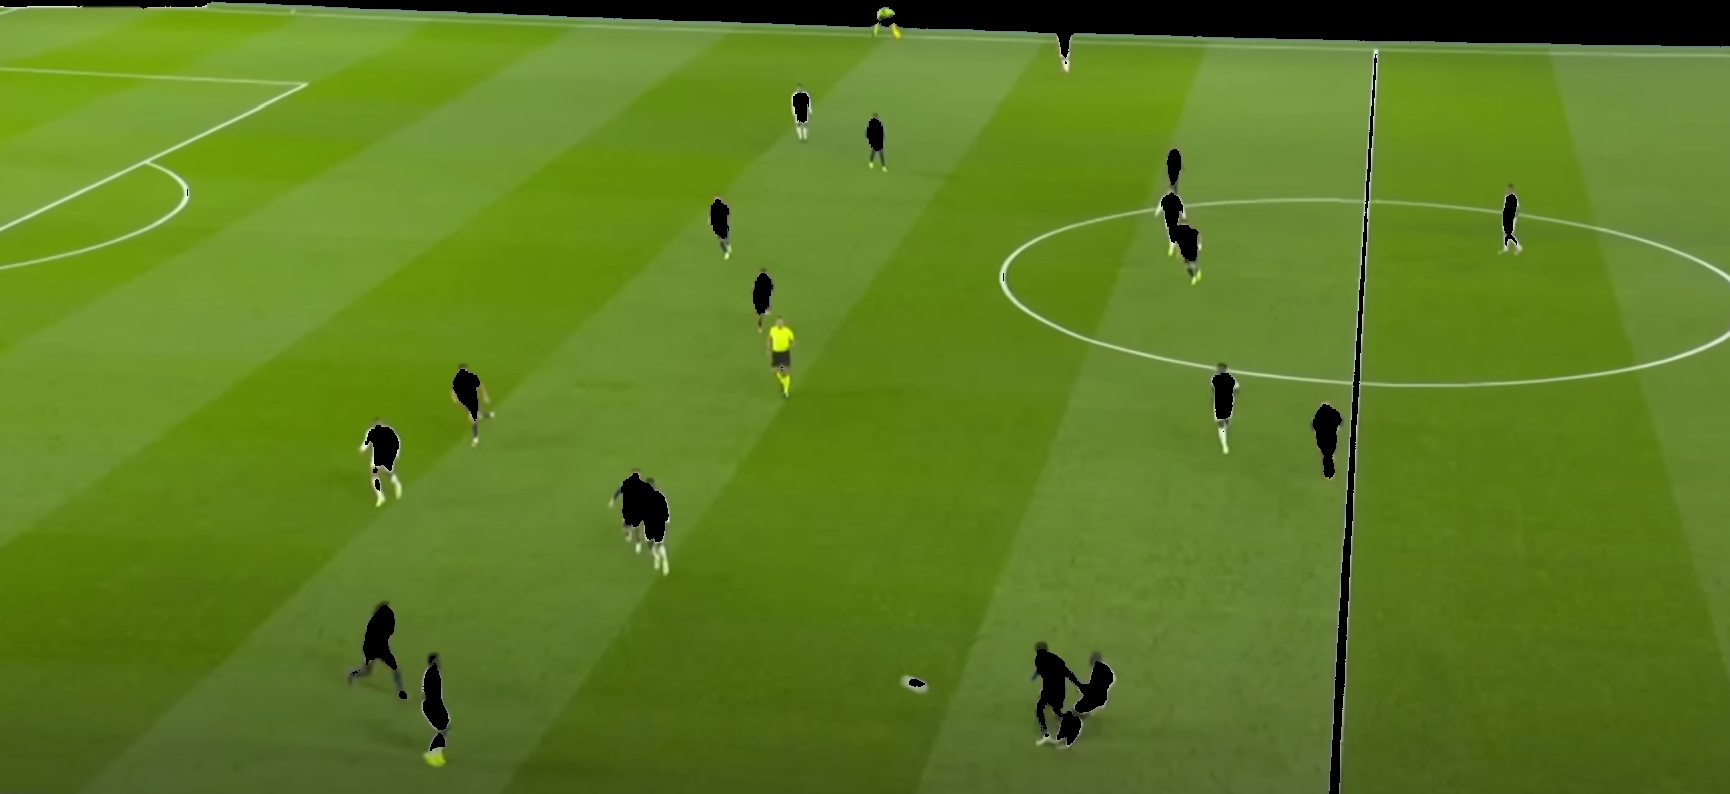

Warna Rumput (HSV): [ 41 184 130]


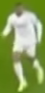

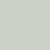

Jersey Player 1:  [     200.11      209.14      204.48]


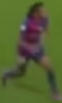

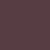

Jersey Player 2:  [     67.704      61.355      87.799]


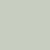

Jersey Player 3:  [     192.82      205.34      199.35]


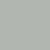

Jersey Player 4:  [     176.15      182.53      177.55]


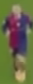

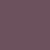

Jersey Player 5:  [     93.213      81.031      108.98]


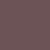

Jersey Player 6:  [      85.79       83.57      108.68]


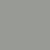

Jersey Player 7:  [     150.21       154.4      152.91]


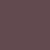

Jersey Player 8:  [     79.007      74.956      98.652]


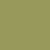

Jersey Player 9:  [         91       153.5       152.5]


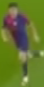

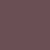

Jersey Player 10:  [     83.961      78.825      105.26]


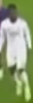

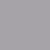

Jersey Player 11:  [     168.64      163.35      166.54]


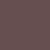

Jersey Player 12:  [     80.653      79.236      102.02]


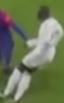

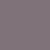

Jersey Player 13:  [     121.82      115.94      127.84]


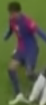

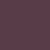

Jersey Player 14:  [     72.676      60.693      88.973]


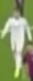

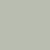

Jersey Player 15:  [     176.04      189.41      185.32]


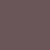

Jersey Player 16:  [     88.277      85.559      106.45]


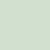

Jersey Player 17:  [     209.55      223.17      211.88]


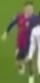

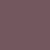

Jersey Player 18:  [      94.46      87.629      115.54]


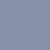

Jersey Player 19:  [     169.69      144.44      135.64]


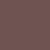

Jersey Player 20:  [     81.834      83.366      111.76]


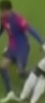

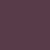

Jersey Player 22:  [     73.039      59.885      88.073]
Warna semua jersey:
[     200.11      209.14      204.48]
[     67.704      61.355      87.799]
[     192.82      205.34      199.35]
[     176.15      182.53      177.55]
[     93.213      81.031      108.98]
[      85.79       83.57      108.68]
[     150.21       154.4      152.91]
[     79.007      74.956      98.652]
[         91       153.5       152.5]
[     83.961      78.825      105.26]
[     168.64      163.35      166.54]
[     80.653      79.236      102.02]
[     121.82      115.94      127.84]
[     72.676      60.693      88.973]
[     176.04      189.41      185.32]
[     88.277      85.559      106.45]
[     209.55      223.17      211.88]
[      94.46      87.629      115.54]
[     169.69      144.44      135.64]
[     81.834      83.366      111.76]
[     73.039      59.885      88.073]


In [15]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
from google.colab.patches import cv2_imshow

# Fungsi deteksi warna dominan jersey tanpa pengaruh lapangan
def get_jersey_color(player_img, grass_hsv):
    # Ambil bagian atas pemain (biasanya area jersey)
    top_img_hlf = player_img[0:int(player_img.shape[0] / 3), :]

    # Konversi ke HSV untuk menghilangkan warna hijau
    hsv_img = cv2.cvtColor(top_img_hlf, cv2.COLOR_BGR2HSV)

    # Buat rentang threshold hijau berdasarkan rumput
    lower_green = np.array([grass_hsv[0] - 10, 40, 40])
    upper_green = np.array([grass_hsv[0] + 10, 255, 255])

    # Masking hijau
    green_mask = cv2.inRange(hsv_img, lower_green, upper_green)
    non_green_mask = cv2.bitwise_not(green_mask)

    # Hanya ambil piksel yang bukan hijau
    masked_img = cv2.bitwise_and(top_img_hlf, top_img_hlf, mask=non_green_mask)

    # Hanya ambil piksel non-0 untuk clustering
    pixels = masked_img.reshape(-1, 3)
    pixels = pixels[np.any(pixels != [0, 0, 0], axis=1)]

    # Jika tidak ada piksel yang tersisa, fallback ke rata-rata
    if len(pixels) == 0:
        return cv2.mean(top_img_hlf)[:3]

    # KMeans untuk cari warna dominan
    kmeans = KMeans(n_clusters=1, init='k-means++', n_init=10)
    kmeans.fit(pixels)
    jersey_color = kmeans.cluster_centers_[0]

    return jersey_color

# --- IDENTIFIKASI WARNA RUMPUT DULU ---
img = result.orig_img.copy()
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_green = np.array([30, 40, 40])
upper_green = np.array([80, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)
masked_img = cv2.bitwise_and(img, img, mask=mask)
cv2_imshow(masked_img)
grass_color = cv2.mean(img, mask=mask)[:3]
grass_hsv = cv2.cvtColor(np.uint8([[list(grass_color)]]), cv2.COLOR_BGR2HSV)[0][0]
print("Warna Rumput (HSV):", grass_hsv)

# --- AMBIL WARNA JERSEY UNTUK SETIAP PEMAIN ---
jersey_colors = []

for i, box in enumerate(result.boxes):
    label = int(box.cls.cpu().numpy()[0])
    if label == 2:  # label 2 = pemain
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        player_img = result.orig_img.copy()[y1:y2, x1:x2]

        # Tampilkan pemain
        cv2_imshow(player_img)

        # Dapatkan warna jersey tanpa gangguan lapangan
        jersey_color = get_jersey_color(player_img, grass_hsv)

        # Simpan
        jersey_colors.append(jersey_color)

        # Visualisasi warna
        demo_color = np.ones((50, 50, 3), dtype=np.uint8) * np.array(jersey_color).astype(np.uint8)
        cv2_imshow(demo_color)
        print(f"Jersey Player {i+1}: ", jersey_color)

# Semua jersey yang terdeteksi
print("Warna semua jersey:")
for c in jersey_colors:
    print(c)


In [16]:
# Lakukan clustering jersey warna
from sklearn.cluster import KMeans
n_teams = 3  # Jumlah tim yang kamu ingin deteksi
kmeans = KMeans(n_clusters=n_teams, random_state=42)
kmeans.fit(jersey_colors)

# Simpan label cluster ke setiap pemain
jersey_labels = kmeans.labels_

# Tampilkan hasil cluster tiap pemain
print("Label cluster masing-masing pemain:")
for i, label in enumerate(jersey_labels):
    print(f"Pemain {i+1}: Tim {label}")


Label cluster masing-masing pemain:
Pemain 1: Tim 2
Pemain 2: Tim 1
Pemain 3: Tim 2
Pemain 4: Tim 2
Pemain 5: Tim 1
Pemain 6: Tim 1
Pemain 7: Tim 0
Pemain 8: Tim 1
Pemain 9: Tim 0
Pemain 10: Tim 1
Pemain 11: Tim 0
Pemain 12: Tim 1
Pemain 13: Tim 0
Pemain 14: Tim 1
Pemain 15: Tim 2
Pemain 16: Tim 1
Pemain 17: Tim 2
Pemain 18: Tim 1
Pemain 19: Tim 0
Pemain 20: Tim 1
Pemain 21: Tim 1


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [17]:
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

# Hitung Silhouette Score
score = silhouette_score(jersey_colors, jersey_labels)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.6267


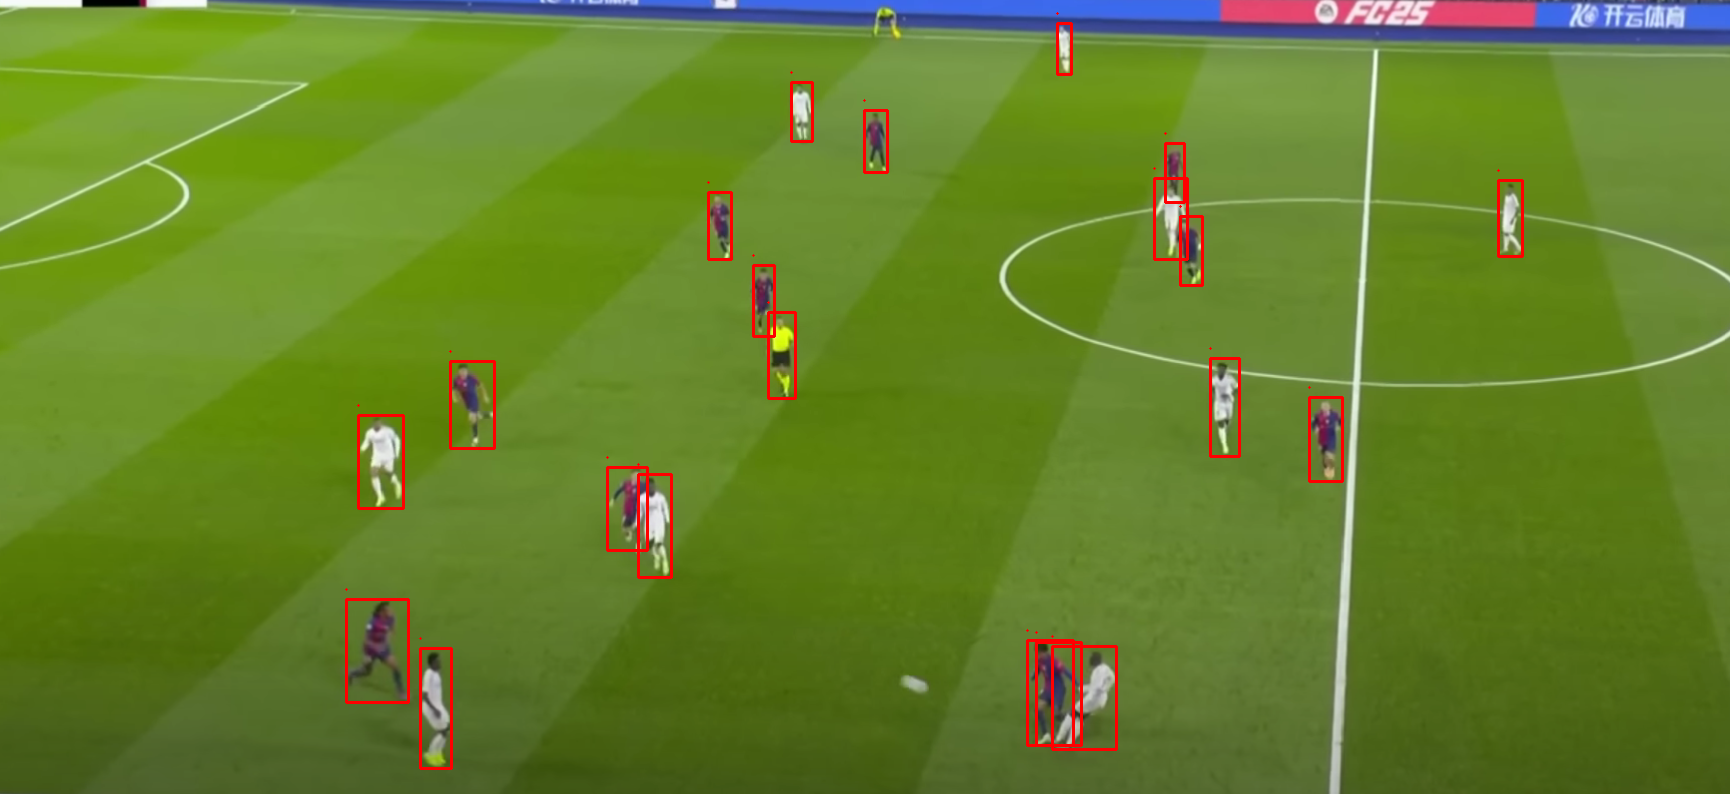

In [18]:
img = result.orig_img.copy()
i = 0
for box in result.boxes:
  label = int(box.cls.cpu().numpy()[0])

  if label == 2:  # ubah ini dari 0 ke 2
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())

    # Draw the bounding box and label
    cv2.rectangle(img, (x1, y1), (x2, y2), box_colors[int(label)], 2)
    team = jersey_labels[i]
    cv2.putText(img, f"Team {team}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0., box_colors[int(label)], 2)
    i += 1

cv2_imshow(img)

Attacking Team Coordinates:
player_0: (380, 461)
player_2: (1510, 218)
player_3: (1224, 407)
player_14: (1170, 218)
player_16: (801, 111)

Defending Team Coordinates:
player_1: (377, 650)
player_4: (1325, 439)
player_5: (719, 225)
player_7: (875, 141)
player_9: (472, 404)
player_11: (763, 300)
player_13: (1050, 692)
player_15: (1191, 250)
player_17: (627, 508)
player_19: (1174, 172)
player_20: (1058, 693)


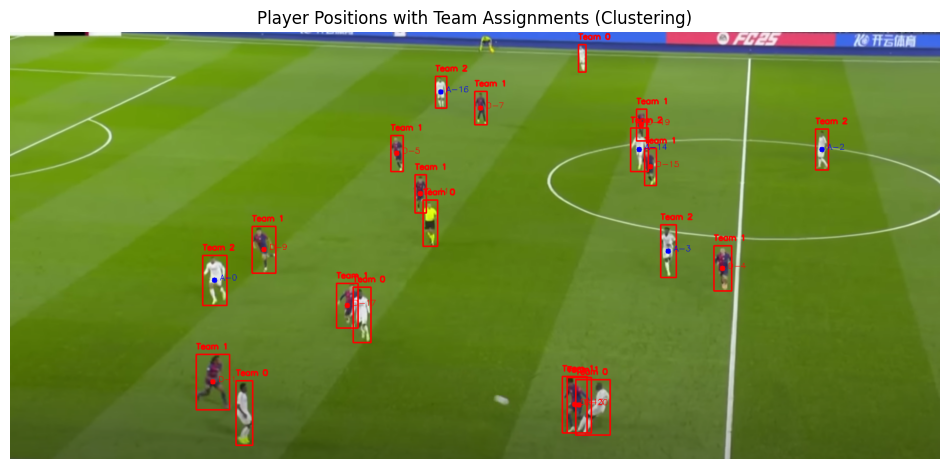

In [19]:
import matplotlib.pyplot as plt
# Ambil gambar asli
img = result.orig_img.copy()

# Inisialisasi penyimpanan koordinat berdasarkan tim
attacking_team_coordinates = {}
defending_team_coordinates = {}
other_team_coordinates = {}

# Inisialisasi indeks pemain
i = 0

# Iterasi setiap bounding box hasil deteksi
for box in result.boxes:
    label = int(box.cls.cpu().numpy()[0])

    if label == 2:  # hanya untuk pemain
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2

        # Ambil label tim dari hasil clustering jersey warna
        team_label = jersey_labels[i]  # 0 atau 1
        player_id = f"player_{i}"

        # Simpan koordinat berdasarkan tim
        if team_label == 2:
            attacking_team_coordinates[player_id] = (center_x, center_y)
        elif team_label == 1:
            defending_team_coordinates[player_id] = (center_x, center_y)
        else:
            other_team_coordinates[player_id] = (center_x, center_y)

        # Gambar bounding box dan label tim
        cv2.rectangle(img, (x1, y1), (x2, y2), box_colors[label], 2)
        cv2.putText(img, f"Team {team_label}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_colors[label], 2)

        i += 1

# Cetak koordinat
print("Attacking Team Coordinates:")
for player, coords in attacking_team_coordinates.items():
    print(f"{player}: {coords}")

print("\nDefending Team Coordinates:")
for player, coords in defending_team_coordinates.items():
    print(f"{player}: {coords}")

# Visualisasi hasil
plt.figure(figsize=(12, 8))
img_with_teams = img.copy()

for player_id, (x, y) in attacking_team_coordinates.items():
    cv2.circle(img_with_teams, (x, y), 5, (255, 0, 0), -1)  # Merah
    cv2.putText(img_with_teams, f"A-{player_id.split('_')[-1]}", (x + 10, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

for player_id, (x, y) in defending_team_coordinates.items():
    cv2.circle(img_with_teams, (x, y), 5, (0, 0, 255), -1)  # Biru
    cv2.putText(img_with_teams, f"D-{player_id.split('_')[-1]}", (x + 10, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.imshow(cv2.cvtColor(img_with_teams, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Player Positions with Team Assignments (Clustering)")
plt.show()


Attacking Team Coordinates:
player_0: (380, 461)
player_2: (1510, 218)
player_3: (1224, 407)
player_14: (1170, 218)
player_16: (801, 111)

Defending Team Coordinates:
player_1: (377, 650)
player_4: (1325, 439)
player_5: (719, 225)
player_7: (875, 141)
player_9: (472, 404)
player_11: (763, 300)
player_13: (1050, 692)
player_15: (1191, 250)
player_17: (627, 508)
player_19: (1174, 172)
player_20: (1058, 693)


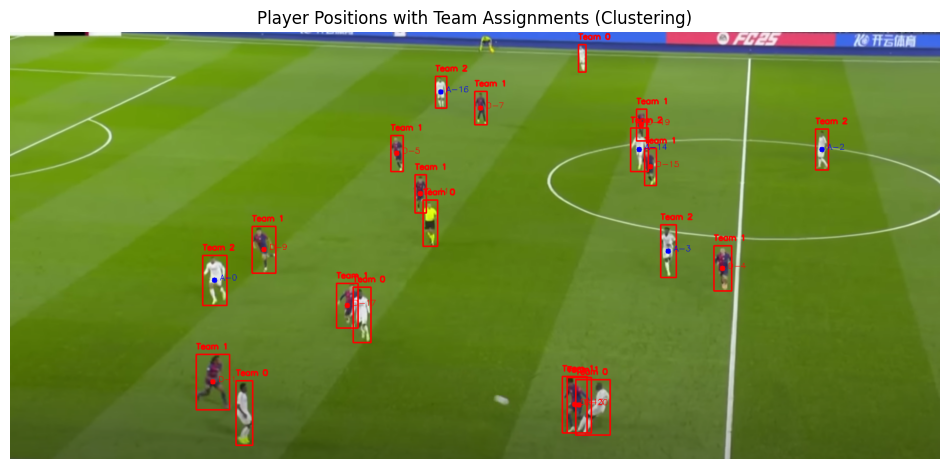

In [20]:
# Cetak koordinat
print("Attacking Team Coordinates:")
for player, coords in attacking_team_coordinates.items():
    print(f"{player}: {coords}")

print("\nDefending Team Coordinates:")
for player, coords in defending_team_coordinates.items():
    print(f"{player}: {coords}")

# Visualisasi hasil
plt.figure(figsize=(12, 8))
img_with_teams = img.copy()

for player_id, (x, y) in attacking_team_coordinates.items():
    cv2.circle(img_with_teams, (x, y), 5, (255, 0, 0), -1)  # Merah
    cv2.putText(img_with_teams, f"A-{player_id.split('_')[-1]}", (x + 10, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

for player_id, (x, y) in defending_team_coordinates.items():
    cv2.circle(img_with_teams, (x, y), 5, (0, 0, 255), -1)  # Biru
    cv2.putText(img_with_teams, f"D-{player_id.split('_')[-1]}", (x + 10, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

plt.imshow(cv2.cvtColor(img_with_teams, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Player Positions with Team Assignments (Clustering)")
plt.show()

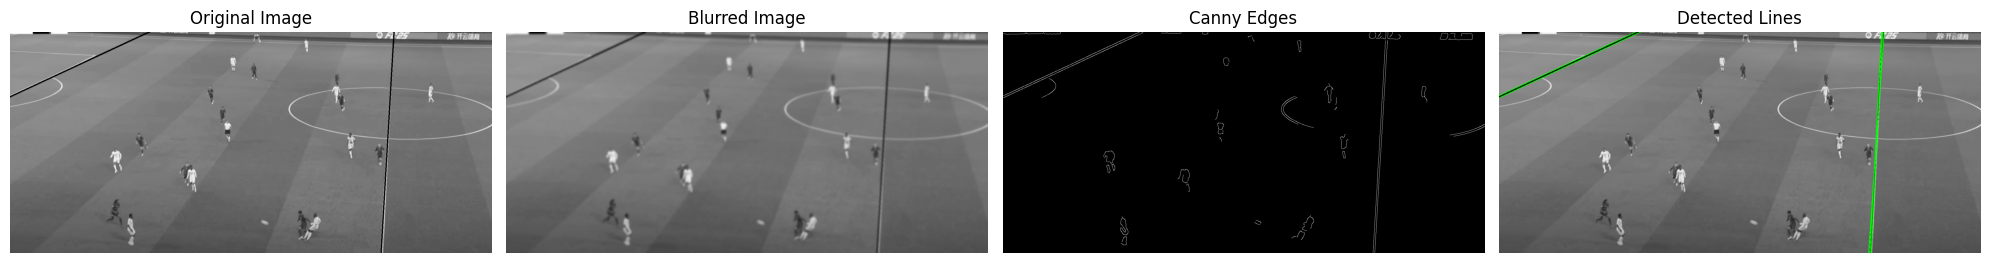

In [29]:
def houghLineTransform():
    # Load image (change path to your Kaggle dataset path)
    img_path = '/kaggle/input/datacobabaru/mbappe 1 garis.png'
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print("Error: Image not loaded. Check the file path.")
        return
    
    # Preprocessing
    img_blur = cv2.GaussianBlur(img, (21, 21), 3)
    canny_edge = cv2.Canny(img_blur, 50, 100)
    
    # Hough Line Transform
    dist_resol = 1
    angle_resol = np.pi/180
    threshold = 160
    lines = cv2.HoughLines(canny_edge, dist_resol, angle_resol, threshold)
    
    # Create a copy of original image for drawing lines
    img_with_lines = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    if lines is not None:
        k = 3000  # Length factor for lines
        for line in lines:
            rho, theta = line[0]
            dhat = np.array([[np.cos(theta)], [np.sin(theta)]])
            d = rho * dhat
            lhat = np.array([[-np.sin(theta)], [np.cos(theta)]])
            p1 = d + k * lhat
            p2 = d - k * lhat
            p1 = p1.astype(int)
            p2 = p2.astype(int)
            cv2.line(img_with_lines, (p1[0][0], p1[1][0]), (p2[0][0], p2[1][0]), (0, 255, 0), 2)
    
    # Display results
    plt.figure(figsize=(20, 5))
    
    plt.subplot(141)
    plt.title("Original Image")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(142)
    plt.title("Blurred Image")
    plt.imshow(img_blur, cmap='gray')
    plt.axis('off')
    
    plt.subplot(143)
    plt.title("Canny Edges")
    plt.imshow(canny_edge, cmap='gray')
    plt.axis('off')
    
    plt.subplot(144)
    plt.title("Detected Lines")
    plt.imshow(img_with_lines)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    return lines, img.shape

if __name__ == '__main__':
    houghLineTransform()

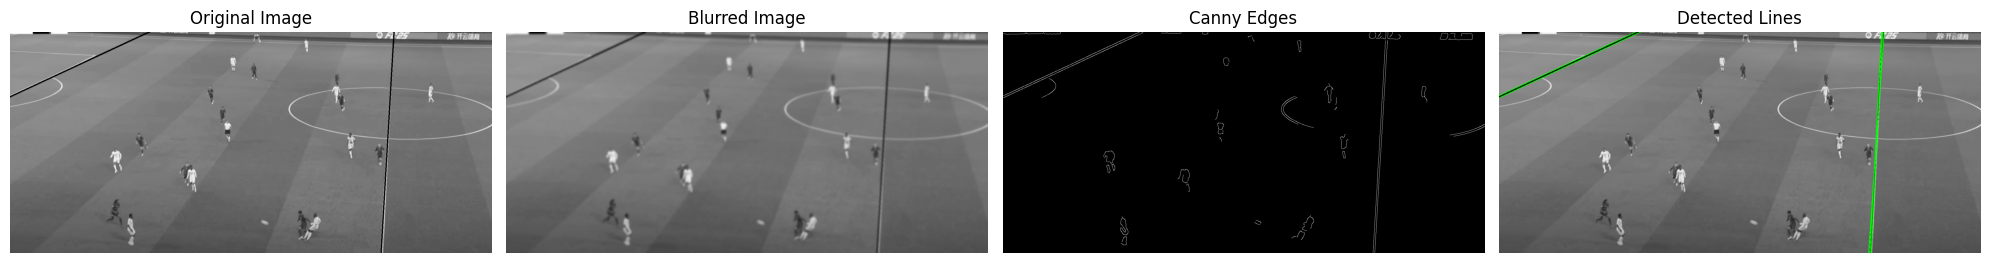

Vanishing point: [     1396.8      -419.1]


In [30]:
def find_vanishing_point(lines, img_shape):
    intersections = []
    height, width = img_shape[:2]
    
    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            rho1, theta1 = lines[i][0]
            rho2, theta2 = lines[j][0]
            
            # Dapatkan persamaan garis: a1x + b1y = rho1
            a1, b1 = np.cos(theta1), np.sin(theta1)
            a2, b2 = np.cos(theta2), np.sin(theta2)
            
            # Hitung determinan
            det = a1*b2 - a2*b1
            
            if abs(det) > 1e-6:  # Garis tidak paralel
                x = (b2*rho1 - b1*rho2) / det
                y = (a1*rho2 - a2*rho1) / det
                intersections.append((x, y))
    
    if not intersections:
        return None
    # Hitung median untuk menghindari outlier
    vanishing_point = np.median(intersections, axis=0)
    return vanishing_point
    
if __name__ == '__main__':
    lines, img_shape = houghLineTransform()
    
    if lines is not None:
        vanishing_point = find_vanishing_point(lines, img_shape)
        print("Vanishing point:", vanishing_point)
    else:
        print("Tidak ada garis yang terdeteksi.")

In [33]:
def plot_extended_with_vanishing_point(img, vp):
    height, width = img.shape[:2]
    vp_x, vp_y = vp

    # Tentukan batas plot: ambil batas max antara ukuran gambar dan posisi vanishing point
    margin = 300  # biar ada sedikit ruang tambahan
    plot_width = int(max(width, vp_x) + margin)
    plot_height = int(max(height, vp_y) + margin)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), extent=[0, width, height, 0])

    # Titik lenyap
    plt.scatter([vp_x], [vp_y], color='red', s=100, label='Vanishing Point')

    plt.title("Vanishing Point in Extended Plot")
    plt.legend()

    # Atur batas axis agar lebih luas dari gambar
    plt.xlim(-1600, plot_width)
    plt.ylim(plot_height, -800)  # y-axis inverted (0 di atas)

    plt.axis("on")
    plt.grid(True)
    plt.show()

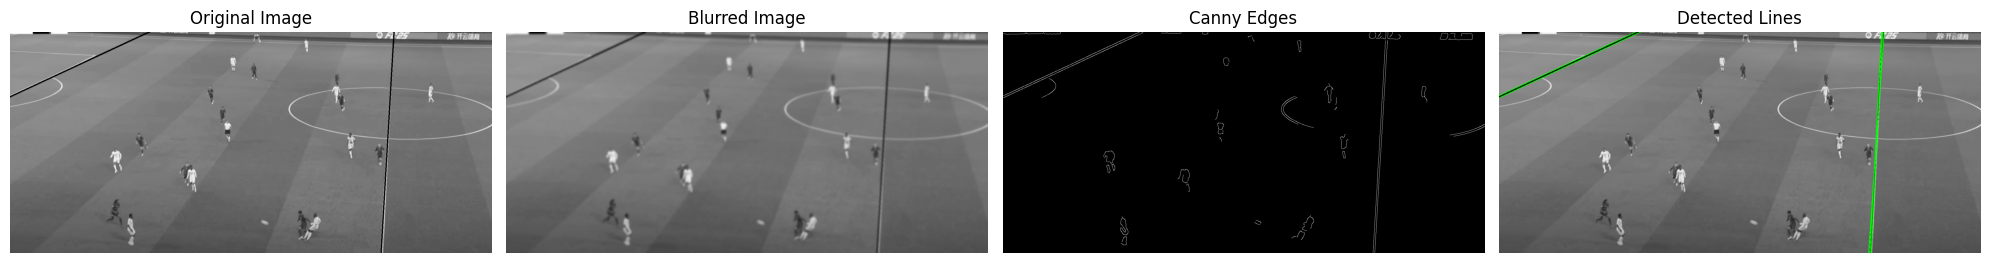

Vanishing Point: [     1396.8      -419.1]


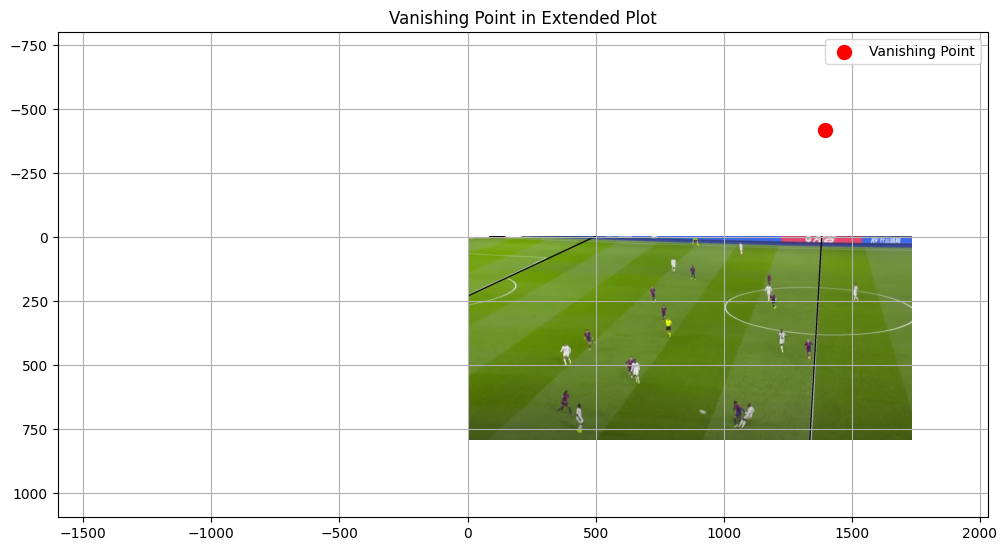

In [35]:
img = cv2.imread('/kaggle/input/datacobabaru/mbappe 1 garis.png')  # Gambar asli berwarna
lines, img_shape = houghLineTransform()  # hasil dari fungsi kamu sebelumnya

if lines is not None:
    vp = find_vanishing_point(lines, img_shape)  # titik lenyap (x, y)
    
    if vp is not None:
        print("Vanishing Point:", vp)
        plot_extended_with_vanishing_point(img, vp)  #panggil fungsi plotting di sini
    else:
        print("Vanishing point tidak ditemukan.")
else:
    print("Garis tidak terdeteksi.")

In [54]:
def calculate_player_angle(player_coords, vp):
    dy = player_coords[0] - vp[0]
    dx = player_coords[1] - vp[1]
    angle = np.arctan2(dx, dy) 
    return angle


def analyze_offside(attacking_coords, defending_coords, vp):
    print("\n--- Analyzing Offside Based on Vanishing Point ---")

    # Attacking team
    max_attack_angle = -np.inf
    max_attack_player = None
    for player, coord in attacking_coords.items():
        angle = (calculate_player_angle(coord, vp))
        if angle > max_attack_angle:
            max_attack_angle = angle
            max_attack_player = player

    # Defending team
    max_defend_angle = -np.inf
    max_defend_player = None
    for player, coord in defending_coords.items():
        angle = (calculate_player_angle(coord, vp))
        if angle > max_defend_angle:
            max_defend_angle = angle
            max_defend_player = player

    # Decision
    if max_attack_angle > max_defend_angle:
        print("\n🚨 OFFSIDE DETECTED!")
        offside = 1
    else:
        print("\n✅ No offside detected.")
        offside = 0

    # Output
    print(f"\nFarthest Attacking Player: {max_attack_player} (Angle: {np.degrees(max_attack_angle):.2f}°)")
    print(f"Last Defending Player:     {max_defend_player} (Angle: {np.degrees(max_defend_angle):.2f}°)")
    print("--------------------------------------------------")

    return offside, max_attack_player, max_defend_player

In [55]:
offside, max_attack_player, max_defend_player = analyze_offside(
    attacking_team_coordinates,
    defending_team_coordinates,
    vp
)


--- Analyzing Offside Based on Vanishing Point ---

🚨 OFFSIDE DETECTED!

Farthest Attacking Player: player_0 (Angle: 139.12°)
Last Defending Player:     player_9 (Angle: 138.33°)
--------------------------------------------------


In [58]:
def calculate_player_angle(player_coord, vp):
    dy = player_coord[0] - vp[0]
    dx = player_coord[1] - vp[1]
    return np.arctan2(dx, dy)

def plot_max_players_and_offside(img, vp, attackers, defenders):
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # Vanishing Point
    plt.scatter([vp[0]], [vp[1]], color='red', s=100, label='Vanishing Point')

    # Cari max defender
    max_defend_angle = -np.inf
    maxdef_coord = None
    for name, coord in defenders.items():
        angle = calculate_player_angle(coord, vp)
        if angle > max_defend_angle:
            max_defend_angle = angle
            maxdef_coord = coord
            maxdef_name = name

    # Cari max attacker
    max_attack_angle = -np.inf
    maxatt_coord = None
    for name, coord in attackers.items():
        angle = calculate_player_angle(coord, vp)
        if angle > max_attack_angle:
            max_attack_angle = angle
            maxatt_coord = coord
            maxatt_name = name

    # Gambar garis offside dari max defender
    if maxdef_coord:
        x1, y1 = vp
        x2, y2 = maxdef_coord
        dx, dy = x2 - x1, y2 - y1
        norm = np.sqrt(dx**2 + dy**2)
        dx /= norm
        dy /= norm
        length = 5000
        line_x1 = x1 - dx * length
        line_y1 = y1 - dy * length
        line_x2 = x1 + dx * length
        line_y2 = y1 + dy * length
        plt.plot([line_x1, line_x2], [line_y1, line_y2], 'lime', label='Garis Offside', linewidth=2)
        plt.scatter(x2, y2, color='green')
        plt.text(x2 + 5, y2, f"{maxdef_name} (Def)", color='green')

    # Gambar attacker terjauh
    if maxatt_coord:
        xa, ya = maxatt_coord
        plt.scatter(xa, ya, color='blue')
        plt.text(xa + 5, ya, f"{maxatt_name} (Att)", color='blue')

    # Set axis dan tampilkan
    margin = 300
    plt.xlim(-1600, max(img.shape[1], vp[0] + margin))
    plt.ylim(max(img.shape[0], vp[1] + margin), -600)
    plt.legend()
    plt.title("Max Defender, Attacker, & Offside Line")
    plt.grid(True)
    plt.show()

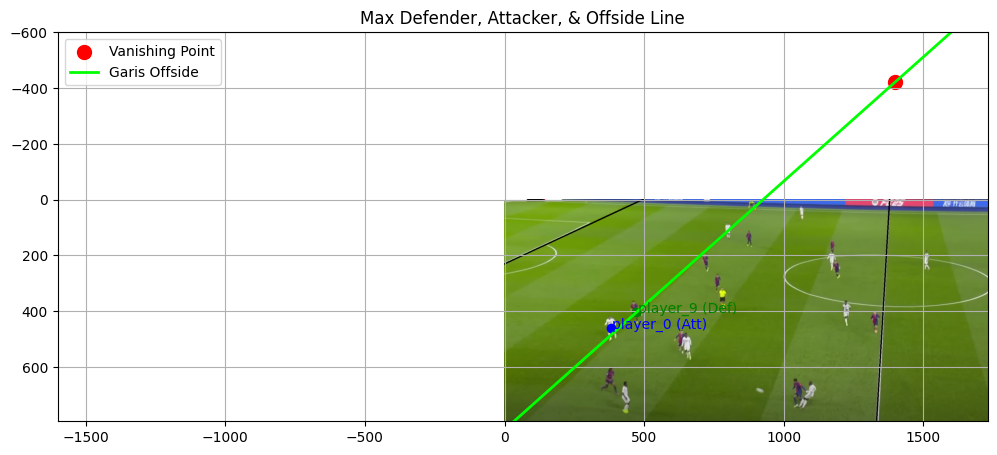

In [59]:
plot_max_players_and_offside(img, vp, attacking_team_coordinates, defending_team_coordinates)